In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, quantitative research aesthetic
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Define target files based on your folder structure
TARGET_FPR = 0.05
N_FEATURES = 2**14

# Update these paths if your notebook is in a different relative directory
result_file = f"results/result_{TARGET_FPR}_{N_FEATURES}.csv"
baseline_file = f"results/baseline_{TARGET_FPR}_{N_FEATURES}.csv"

print(f"Targeting files:\n- {result_file}\n- {baseline_file}")

Targeting files:
- results/result_0.05_16384.csv
- results/baseline_0.05_16384.csv


In [16]:
# 1. Load Data
try:
    lbf_df = pd.read_csv(result_file)
    baseline_df = pd.read_csv(baseline_file)
    print("Data loaded successfully.")
except FileNotFoundError as e:
    print(f"Error loading files: {e}")

# 2. Extract Baseline Metrics (Averaged across trials)
base_latency = baseline_df['time_per_query_ns'].mean()
base_memory = baseline_df['memory_mb'].mean()
base_throughput = baseline_df['throughtput_s'].mean()

# 3. Find the "Optimal" LBF (Minimizing Memory while keeping Latency reasonable)
# We sort by total memory, then pick the one with the lowest memory footprint
optimal_lbf = lbf_df.sort_values(by=['total_memory_mb', 'time_per_query_ns']).iloc[0]

print(f"\n--- Baseline (Standard Bloom Filter) ---")
print(f"Memory:  {base_memory:.4f} MB")
print(f"Latency: {base_latency:.2f} ns/query")

print(f"\n--- Optimal Learned Bloom Filter ---")
print(f"Threshold: {optimal_lbf['threshold']}")
print(f"Memory:    {optimal_lbf['total_memory_mb']:.4f} MB")
print(f"Latency:   {optimal_lbf['time_per_query_ns']:.2f} ns/query")

Data loaded successfully.

--- Baseline (Standard Bloom Filter) ---
Memory:  0.1487 MB
Latency: 68.66 ns/query

--- Optimal Learned Bloom Filter ---
Threshold: 0.2749999999999999
Memory:    0.0691 MB
Latency:   970.30 ns/query


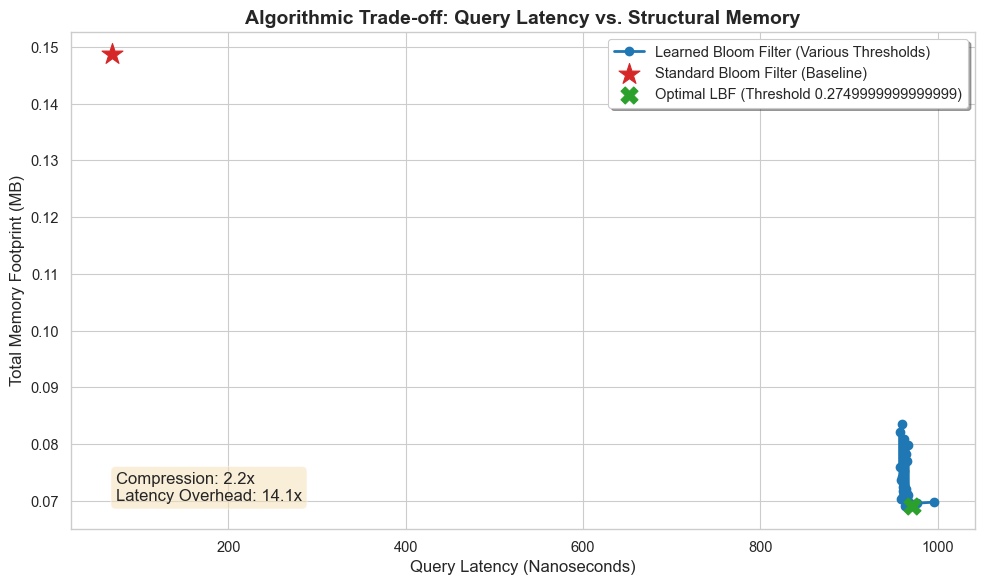

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by latency to create a smooth curve
lbf_sorted = lbf_df.sort_values('time_per_query_ns')

# Plot LBF Curve
ax.plot(lbf_sorted['time_per_query_ns'], lbf_sorted['total_memory_mb'], 
        marker='o', markersize=6, linestyle='-', linewidth=2, 
        color='#1f77b4', label='Learned Bloom Filter (Various Thresholds)')

# Plot Baseline
ax.scatter([base_latency], [base_memory], 
           color='#d62728', s=250, marker='*', zorder=5, 
           label='Standard Bloom Filter (Baseline)')

# Highlight the Optimal LBF point
ax.scatter([optimal_lbf['time_per_query_ns']], [optimal_lbf['total_memory_mb']], 
           color='#2ca02c', s=150, marker='X', zorder=5, 
           label=f'Optimal LBF (Threshold {optimal_lbf["threshold"]})')

# Annotations & Styling
ax.set_title('Algorithmic Trade-off: Query Latency vs. Structural Memory', fontweight='bold')
ax.set_xlabel('Query Latency (Nanoseconds)')
ax.set_ylabel('Total Memory Footprint (MB)')
ax.legend(loc='upper right', frameon=True, shadow=True)

# Add a text box with the compression ratio
compression_ratio = base_memory / optimal_lbf['total_memory_mb']
latency_multiplier = optimal_lbf['time_per_query_ns'] / base_latency
textstr = f"Compression: {compression_ratio:.1f}x\nLatency Overhead: {latency_multiplier:.1f}x"
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax.text(0.05, 0.05, textstr, transform=ax.transAxes, fontsize=12,
        verticalalignment='bottom', bbox=props)

plt.tight_layout()
plt.savefig(f'visuals/pareto_frontier_{TARGET_FPR}_{N_FEATURES}.png', dpi=300)
plt.show()

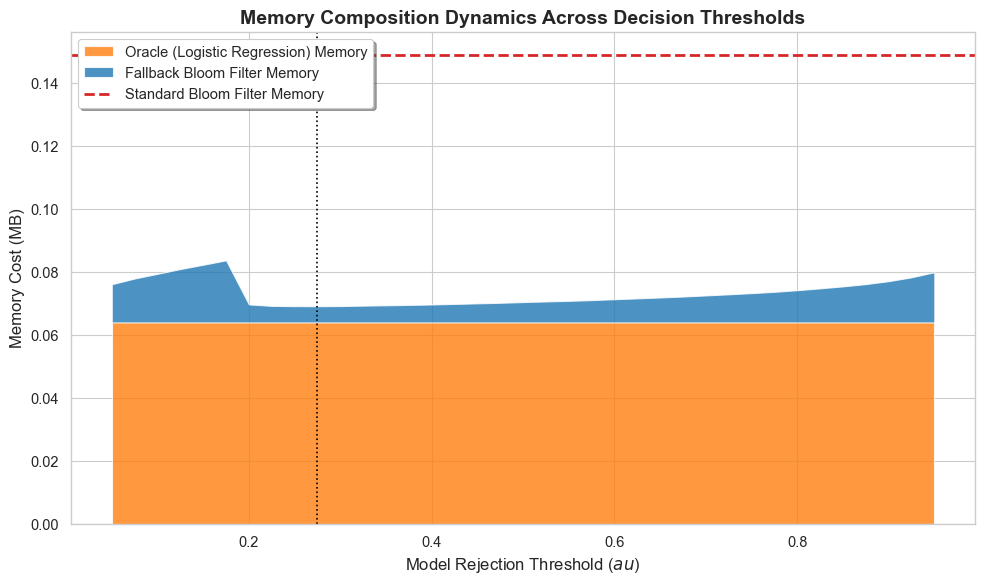

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by threshold for the x-axis
lbf_thresh = lbf_df.sort_values('threshold')

x = lbf_thresh['threshold']
y1 = lbf_thresh['model_memory_mb']
y2 = lbf_thresh['backup_memory_mb']

# Stack plot
ax.stackplot(x, y1, y2, labels=['Oracle (Logistic Regression) Memory', 'Fallback Bloom Filter Memory'],
             colors=['#ff7f0e', '#1f77b4'], alpha=0.8)

# Add baseline reference line
ax.axhline(base_memory, color='#d62728', linestyle='--', linewidth=2, label='Standard Bloom Filter Memory')

ax.set_title('Memory Composition Dynamics Across Decision Thresholds', fontweight='bold')
ax.set_xlabel('Model Rejection Threshold ($\tau$)')
ax.set_ylabel('Memory Cost (MB)')
ax.legend(loc='upper left', frameon=True, shadow=True)

# Highlight the sweet spot
ax.axvline(optimal_lbf['threshold'], color='black', linestyle=':', label='Optimal $\tau$')

plt.tight_layout()
plt.savefig(f'visuals/memory_composition.png_{TARGET_FPR}_{N_FEATURES}.png', dpi=300)
plt.show()

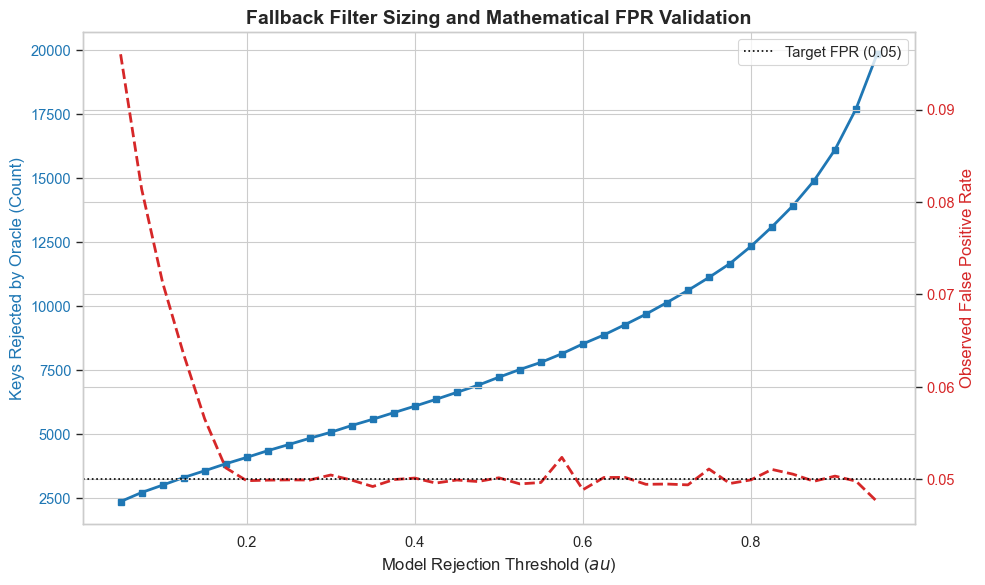

In [19]:
fig, ax1 = plt.subplots(figsize=(10, 6))

x = lbf_thresh['threshold']

# Axis 1: Items pushed to backup filter
color = '#1f77b4'
ax1.set_xlabel('Model Rejection Threshold ($\tau$)')
ax1.set_ylabel('Keys Rejected by Oracle (Count)', color=color)
ax1.plot(x, lbf_thresh['backup_key_count'], color=color, linewidth=2, marker='s', markersize=4)
ax1.tick_params(axis='y', labelcolor=color)

# Axis 2: Observed FPR
ax2 = ax1.twinx()  
color = '#d62728'
ax2.set_ylabel('Observed False Positive Rate', color=color)  
ax2.plot(x, lbf_thresh['observed_fpr'], color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

# Add Target FPR reference line
ax2.axhline(TARGET_FPR, color='black', linestyle=':', label=f'Target FPR ({TARGET_FPR})')
ax2.legend(loc='upper right')

plt.title('Fallback Filter Sizing and Mathematical FPR Validation', fontweight='bold')
plt.tight_layout()
plt.savefig(f'visuals/fpr_validation_{TARGET_FPR}_{N_FEATURES}.png', dpi=300)
plt.show()